In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import ruptures as rpt

In [2]:
data = pd.read_csv("../data/processed_data/1_datacenter.csv")
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index("timestamp",inplace=True) 

In [3]:
# change point detection

change_points = []

chunk_size=500
model = "rbf"

for i in range(0, len(data), chunk_size):
    chunk = data.iloc[i:i + chunk_size]
    signal = chunk['gpu0_util'].to_numpy()
    algo = rpt.Pelt(model=model).fit(signal)
    result = algo.predict(pen=2) 
    change_points.append(result)

In [4]:
len(change_points)

173

In [5]:
# 重新组织索引，最后一个点可以丢掉，因为无论是否变化都会加上最后一个时刻。
global_len = 0
ground_points = []

for r in change_points:
    if len(r) == 1:
        '''
        No change point in the subsequence
        '''
        global_len += chunk_size
    else:
        '''
        delete the last point, and increase the index by chunk size
        '''
        ground_points += list(map(lambda x: x + global_len, r))[:-1]
        global_len += chunk_size

In [6]:
len(ground_points)

211

总共211个改变点，好少呀。   
check下，是否存在问题。 
方法：通过打印改变点附近的数值

In [7]:
data['gpu0_util'].iloc[ground_points[0]-5: ground_points[0]+5]

timestamp
2025-07-30 12:24:30    0.00
2025-07-30 12:25:00    0.00
2025-07-30 12:25:30    0.02
2025-07-30 12:26:00    0.68
2025-07-30 12:26:30    1.00
2025-07-30 12:27:00    0.70
2025-07-30 12:27:30    1.00
2025-07-30 12:28:00    1.00
2025-07-30 12:28:30    0.80
2025-07-30 12:29:00    1.00
Name: gpu0_util, dtype: float64

In [8]:
data['gpu0_util'].iloc[ground_points[0]]

np.float64(0.7)

上面探测来看，识别错误了2个位置。

In [9]:
data['gpu0_util'].iloc[ground_points[1]]

np.float64(0.0)

In [ ]:
data['gpu0_util'].iloc[ground_points[2]-1: ground_points[2]+2]

In [28]:
print(data.reset_index()['timestamp'].iloc[ground_points[3]])
data['gpu0_util'].iloc[ground_points[3]-2: ground_points[3]+2]

2025-07-31 06:22:00


timestamp
2025-07-31 06:21:00    0.74
2025-07-31 06:21:30    0.00
2025-07-31 06:22:00    0.00
2025-07-31 06:22:30    0.00
Name: gpu0_util, dtype: float64

In [23]:
print(data.reset_index()['timestamp'].iloc[ground_points[2]])
data['gpu0_util'].iloc[ground_points[2]-1: ground_points[2]+2]

2025-07-31 01:24:30


timestamp
2025-07-31 01:24:00    0.0
2025-07-31 01:24:30    0.0
2025-07-31 01:25:00    1.0
Name: gpu0_util, dtype: float64

In [26]:
print(data.reset_index()['timestamp'].iloc[ground_points[1]])
data['gpu0_util'].iloc[ground_points[1]-2: ground_points[1]+2]

2025-07-30 15:12:00


timestamp
2025-07-30 15:11:00    1.0
2025-07-30 15:11:30    0.0
2025-07-30 15:12:00    0.0
2025-07-30 15:12:30    0.0
Name: gpu0_util, dtype: float64

In [14]:
xxx = [1,3,4,5]
xxx += [2,3]
print(xxx)

[1, 3, 4, 5, 2, 3]


In [24]:
# sample = data.loc["2025-07-30 12:00:00": "2025-08-02 17:00:00"]
# signal = sample['gpu0_util'].to_numpy()
# model = "rbf"
# algo = rpt.Pelt(model=model).fit(signal)
# result = algo.predict(pen=2)  # pen 是惩罚项大小，影响分段数量

# # 3. 可视化
# rpt.display(signal, result, figsize=(10, 6))
# plt.title("Change Point Detection with PELT")
# plt.show()

根据前面的分析来看，改变点有错位，需要进一步修订。

这也带来了一个问题，是否直接通过shift错位计算相邻差值，直接阈值判断，识别改变点？

In [29]:
diff_gpu = data['gpu0_util'].diff()
points = diff_gpu.abs() > 0.7 # threshold

points = points[points].index.tolist()


In [26]:
len(points)

984

In [32]:
points[2]

Timestamp('2025-07-31 01:23:00')

<Axes: xlabel='timestamp'>

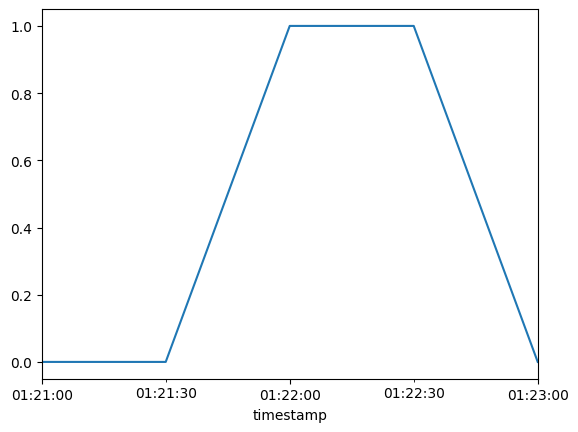

In [31]:
sample = data.loc["2025-07-31 01:21:00":"2025-07-31 01:23:00"]

sample['gpu0_util'].plot()

In [29]:
points[1]

Timestamp('2025-07-31 01:22:00')

<Axes: xlabel='timestamp'>

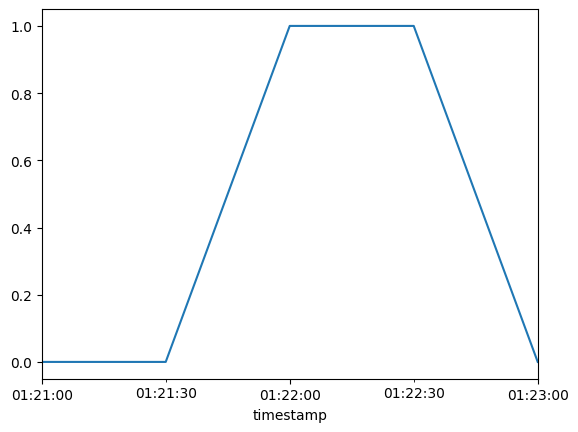

In [30]:
sample = data.loc["2025-07-31 01:21:00":"2025-07-31 01:23:00"]

sample['gpu0_util'].plot()

In [31]:
points[2]

Timestamp('2025-07-31 01:23:00')

# diff阈值判断改变点

In [ ]:
import numpy as np
import pandas as pd

# 读取数据
data = pd.read_csv("../data/processed_data/1_datacenter.csv")
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index("timestamp", inplace=True)

columns = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']
threshold = 0.7

# 用于存储每个GPU突变点的DataFrame
change_points_dict = {}

for col in columns:
    change_points = []
    diff = data[col].diff()
    # 找到绝对值大于阈值的位置
    idx = diff[diff.abs() > threshold].index
    for i in idx:
        # 获取当前值和上一个值
        curr_value = data.loc[i, col]
        prev_value = data.loc[data.index[data.index.get_loc(i)-1], col]

        if curr_value - prev_value > 0:
            change_type = 1  # 上升突变
        else:
            change_type = -1  # 下降突变
        change_points.append([i, change_type, curr_value, prev_value])

    change_points_df = pd.DataFrame(change_points, columns=['timestamp', 'change_type', 'current_value', 'previous_value'])
    change_points_dict[col] = change_points_df

import pickle

with open("../data/processed_data/change_points_dict.pkl", "wb") as f:
    pickle.dump(change_points_dict, f)


In [22]:
import pandas as pd
file_path="../data/processed_data/change_points_dict.pkl"
data=pd.read_pickle(file_path)
print(data)

{'gpu0_util':               timestamp  change_type  current_value  previous_value
0   2025-07-30 15:11:30           -1           0.00            1.00
1   2025-07-31 01:22:00            1           1.00            0.00
2   2025-07-31 01:23:00           -1           0.00            1.00
3   2025-07-31 01:25:00            1           1.00            0.00
4   2025-07-31 06:21:30           -1           0.00            0.74
..                  ...          ...            ...             ...
979 2025-08-28 07:23:00            1           0.97            0.20
980 2025-08-28 07:25:00           -1           0.00            1.00
981 2025-08-28 08:34:00            1           1.00            0.16
982 2025-08-28 09:08:00           -1           0.00            0.92
983 2025-08-28 09:14:00            1           1.00            0.00

[984 rows x 4 columns], 'gpu1_util':               timestamp  change_type  current_value  previous_value
0   2025-07-30 12:26:00            1           1.00            0

## 共同突变点检测

In [74]:

change_points_sets = [set(df['timestamp']) for df in change_points_dict.values()]


if change_points_sets:
    common_change_points = set.intersection(*change_points_sets)
else:
    common_change_points = set()

common_change_points = sorted(list(common_change_points))

print("共同突变点数量：", len(common_change_points))
print("共同突变点时间索引：", common_change_points)


共同突变点数量： 13
共同突变点时间索引： [Timestamp('2025-07-31 01:23:00'), Timestamp('2025-08-07 06:05:00'), Timestamp('2025-08-08 11:35:30'), Timestamp('2025-08-12 01:39:30'), Timestamp('2025-08-13 08:53:00'), Timestamp('2025-08-13 11:11:00'), Timestamp('2025-08-14 10:54:30'), Timestamp('2025-08-14 10:57:30'), Timestamp('2025-08-14 11:23:00'), Timestamp('2025-08-15 03:33:00'), Timestamp('2025-08-15 10:58:00'), Timestamp('2025-08-18 06:08:30'), Timestamp('2025-08-18 06:26:30')]


# 突变点预测效果分析

In [ ]:
import pickle
import numpy as np
import pandas as pd
# 读取预测结果函数（已经放到utils下）
def pred_result(
    file_path='../experiments/timemixer/processed_data/2025-09-13_15:57:13/',
    inverse=True,  # 是否反归一化
    sum_cols=11
):
    """
    mode:
        'flatten'：将所有样本和时间步展开为一条曲线
        'samples'：每个样本单独一个子图，展示多个样本，并标注过去序列
    sample_indices:
        指定要展示的样本索引列表，若为None则默认展示前n_samples个
    var_idx:
        指定要展示的变量索引
    past_offset:
        过去序列的样本偏移量
    train_start, train_end:
        用于计算均值和方差的训练集时间范围
    """
    datasets_index=pickle.load(open(file_path + 'datasets_index.pkl', 'rb'))
    train_start=datasets_index['train'][0].strftime('%Y-%m-%d %H:%M:%S')
    train_end=datasets_index['train'][1].strftime('%Y-%m-%d %H:%M:%S')
    # 读取原始数据，计算所有变量的均值和方差
    data = pd.read_csv('../data/processed_data/1_datacenter.csv')
    data = data.set_index('timestamp')
    all_columns = list(data.columns)
    # 只保留前11列（与预测输出变量数一致）
    mean = data.loc[train_start:train_end].mean().values[:sum_cols]  # shape: (11,)
    std = data.loc[train_start:train_end].std().values[:sum_cols]    # shape: (11,)
    # 加载预测结果
    npz_data = np.load(file_path + 'result.npz')
    pred = npz_data['pred_y']  # (样本数, 序列长度, 变量数=11)
    true = npz_data['real_y']
    # 反归一化（针对每一列）
    if inverse:
        pred = pred * std + mean
        true = true * std + mean
    print(pred.shape, true.shape)
    return pred,true,datasets_index
_,_,_=pred_result()

(17260, 12, 11) (17260, 12, 11)


## 检查索引对齐是否正确
real为原始数据真实值，使用时间索引

true为模型保存真实值，shape为（样本数，pred_len，特征数）

In [13]:
# 改变点数据读取
file_path='../data/processed_data/change_points_dict.pkl'
change_points_dict=pd.read_pickle(file_path)

# 测试集index获取
file_path='../data/processed_data/1_datacenter.csv'
data=pd.read_csv(file_path)
data=data.set_index('timestamp')
columns_cols_dict={'cpu_util': 0, 'gpu0_util': 1, 'gpu1_util': 2, 'gpu2_util': 3, 
                   'gpu3_util': 4, 'gpu4_util': 5, 'gpu5_util': 6, 'gpu6_util': 7, 
                   'gpu7_util': 8,'memory': 9,'power': 10,'Inlet_Temp': 11,'Outlet_Temp1': 12,'Outlet_Temp2': 13}
# 模型预测结果获取
file_path='../experiments/timemixer/processed_data/2025-09-13_15:57:13/'
pred,true,datasets_index=pred_result(
    file_path=file_path,inverse=True,  # 是否反归一化var_idx=1,  # 指定要可视化的变量索引
)
deta=30 # 时间间隔30s
past_len=120 # 过去序列长度为120

# 模型返回的训练集、验证集、测试集index，实际上是包括了历史窗长的，因此需要对齐验证集、测试集结果的index时，需要先往后平移
# 读取datasets_index['test']的起点，往后移120*30s为新的起点，终点不变，间隔为30s
test_start = datasets_index['test'][0] + pd.Timedelta(seconds=past_len*deta)
test_end = datasets_index['test'][1]
aligned_test_index = pd.date_range(start=test_start, end=test_end, freq=f'{deta}S')
real=data.loc[aligned_test_index.strftime('%Y-%m-%d %H:%M:%S')]

# 检验index索引是否正确
print(real.iloc[:3])
print(true.shape)
print(true[0,:3,:])


(17260, 12, 11) (17260, 12, 11)
                     cpu_util  gpu0_util  gpu1_util  gpu2_util  gpu3_util  \
2025-08-22 09:21:30  0.027921        0.0        0.0        0.0        0.0   
2025-08-22 09:22:00  0.026730        0.0        0.0        0.0        0.0   
2025-08-22 09:22:30  0.024160        0.0        0.0        0.0        0.0   

                     gpu4_util  gpu5_util  gpu6_util  gpu7_util  \
2025-08-22 09:21:30        0.0        0.0        0.0        0.0   
2025-08-22 09:22:00        0.0        0.0        0.0        0.0   
2025-08-22 09:22:30        0.0        0.0        0.0        0.0   

                            memory  power  Inlet_Temp  Outlet_Temp1  \
2025-08-22 09:21:30  160072.453125   1661          27            43   
2025-08-22 09:22:00  155965.429688   1684          27            42   
2025-08-22 09:22:30  157789.625000   1674          27            42   

                     Outlet_Temp2  
2025-08-22 09:21:30            29  
2025-08-22 09:22:00            29

/tmp/ipykernel_223165/3790460930.py:24: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  aligned_test_index = pd.date_range(start=test_start, end=test_end, freq=f'{deta}S')


## 改变点与非改变点预测效果评估

In [ ]:
# 改变点数据读取
file_path='../data/processed_data/change_points_dict.pkl'
change_points_dict=pd.read_pickle(file_path)

# 测试集index获取
file_path='../data/processed_data/1_datacenter.csv'
data=pd.read_csv(file_path)
data=data.set_index('timestamp')
columns_cols_dict={'cpu_util': 0, 'gpu0_util': 1, 'gpu1_util': 2, 'gpu2_util': 3, 
                   'gpu3_util': 4, 'gpu4_util': 5, 'gpu5_util': 6, 'gpu6_util': 7, 
                   'gpu7_util': 8,'memory': 9,'power': 10,'Inlet_Temp': 11,'Outlet_Temp1': 12,'Outlet_Temp2': 13}
file_path='../experiments/timemixer/processed_data/2025-09-13_15:57:13/'
pred,true,datasets_index=pred_result(
    file_path=file_path,inverse=False,  # 是否反归一化var_idx=1,  # 指定要可视化的变量索引
)
deta=30 # 时间间隔30s
past_len=120 # 过去序列长度为120

# 模型返回的训练集、验证集、测试集index，实际上是包括了历史窗长的，因此需要对齐验证集、测试集结果的index时，需要先往后平移
# 读取datasets_index['test']的起点，往后移120*30s为新的起点，终点不变，间隔为30s
test_start = datasets_index['test'][0] + pd.Timedelta(seconds=past_len*deta)
test_end = datasets_index['test'][1]
aligned_test_index = pd.date_range(start=test_start, end=test_end, freq=f'{deta}S')
real=data.loc[aligned_test_index.strftime('%Y-%m-%d %H:%M:%S')]

# # 检验index索引是否正确
# print(real.iloc[:3])
# print(true.shape)
# print(true[0,:3])

import sys
sys.path.append('..')
from utils.metrics import MAE_np, SMAPE_np, RMSE_np, R2_np

for var, df in change_points_dict.items():
    col_num = columns_cols_dict[var]
    print("突变点变量：", var)
    var_pred = pred[:, :, col_num]
    var_true = true[:, :, col_num]
    df = df.set_index('timestamp')
    # 上升/下降/所有突变
    cp_timestamps = df[df['change_type'].isin([1])].index
    cp_timestamps = pd.to_datetime(cp_timestamps)
    cp_indices = []
    for ts in cp_timestamps:
        try:
            idx = aligned_test_index.get_loc(ts)
            cp_indices.append(idx)
        except KeyError:
            continue
    cp_indices = sorted(cp_indices)  

    print(var_pred.shape, var_true.shape)
    
    # 统计所有突变点样本的MAE和MSE
    if len(cp_indices) == 0:
        print("无突变点样本")
        continue
    # test_index 比 样本长度多（pred_len-11)
    cp_indices = [idx for idx in cp_indices if idx < var_pred.shape[0]]

    cp_pred_samples = var_pred[cp_indices, :]
    cp_true_samples = var_true[cp_indices, :]
    cp_pred_flat = cp_pred_samples.flatten()
    cp_true_flat = cp_true_samples.flatten()
    mae = MAE_np(np.array(cp_true_flat), np.array(cp_pred_flat))
    smape = SMAPE_np(np.array(cp_true_flat), np.array(cp_pred_flat))
    r2 = R2_np(np.array(cp_true_flat), np.array(cp_pred_flat))
    rmse = RMSE_np(np.array(cp_true_flat), np.array(cp_pred_flat))
    print(f"{var} 突变点样本数量: {len(cp_indices)}")
    print(f"{var} 突变点MAE: {mae:.4f}")
    print(f"{var} 突变点RMSE: {rmse:.4f}")
    print(f"{var} 突变点R2: {r2:.4f}")
    print(f"{var} 突变点SMAPE: {smape:.4f}")


In [ ]:

#  # 突变点附近都为突变区间
# from datetime import timedelta

# window_size = 1  
# interval = pd.Timedelta(seconds=30)  # 时间间隔

# # 获取所有突变点的时间戳集合
# change_points_lists = [list(df['timestamp']) for df in change_points_dict.values()]

# change_points_lists = [
#     [pd.Timestamp(ts) if not isinstance(ts, pd.Timestamp) else ts for ts in lst]
#     for lst in change_points_lists
# ]

# window_sets = []
# for lst in change_points_lists:
#     window_set = set()
#     for ts in lst:
#         for i in range(-window_size, window_size + 1):
#             window_set.add(ts + i * interval)
#     window_sets.append(window_set)

# if window_sets:
#     common_change_points = set.intersection(*window_sets)
# else:
#     common_change_points = set()

# common_change_points = sorted(list(common_change_points))

# print("共同突变点数量：", len(common_change_points))
# print("共同突变点时间索引：", common_change_points)


共同突变点数量： 154
共同突变点时间索引： [Timestamp('2025-07-31 01:22:00'), Timestamp('2025-07-31 01:22:30'), Timestamp('2025-07-31 01:23:00'), Timestamp('2025-07-31 01:23:30'), Timestamp('2025-07-31 01:25:00'), Timestamp('2025-07-31 01:25:30'), Timestamp('2025-07-31 08:06:00'), Timestamp('2025-07-31 08:06:30'), Timestamp('2025-07-31 08:07:00'), Timestamp('2025-07-31 08:07:30'), Timestamp('2025-08-05 01:32:00'), Timestamp('2025-08-05 01:32:30'), Timestamp('2025-08-05 09:34:00'), Timestamp('2025-08-07 06:00:30'), Timestamp('2025-08-07 06:01:00'), Timestamp('2025-08-07 06:04:30'), Timestamp('2025-08-07 06:05:00'), Timestamp('2025-08-07 06:05:30'), Timestamp('2025-08-07 10:31:30'), Timestamp('2025-08-07 10:32:00'), Timestamp('2025-08-08 11:30:30'), Timestamp('2025-08-08 11:31:00'), Timestamp('2025-08-08 11:35:00'), Timestamp('2025-08-08 11:35:30'), Timestamp('2025-08-08 11:36:00'), Timestamp('2025-08-10 12:12:30'), Timestamp('2025-08-10 12:13:00'), Timestamp('2025-08-12 01:39:00'), Timestamp('2025-08-12 0

# Easy Temporal Point Process 数据对齐

## 固定历史序列长度

In [ ]:
import pandas as pd

columns_list = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']

# 初始化突变点时间列全0
file_path = '../data/processed_data/1_datacenter.csv'
data = pd.read_csv(file_path)
data['timestamp'] = data['timestamp'].astype(str)
for col in columns_list:
    changetype_col = f"{col}_changetype"
    data[changetype_col] = 0

# 利用突变点数据填充对应时间的改变点类型， 1代表上升突变点，-1代表下降突变点
data = data.set_index('timestamp')
file_path = '../data/processed_data/change_points_dict.pkl'
all_change_points_data = pd.read_pickle(file_path)
for column in columns_list:
    changetype_col = f"{column}_changetype"
    change_points_data = all_change_points_data[column]
    change_points_data['timestamp'] = change_points_data['timestamp'].astype(str)
    for idx, row in change_points_data.iterrows():
        ts = row['timestamp']
        change_type = row['change_type']
        if ts in data.index:
            data.at[ts, changetype_col] = change_type

def timeseries_to_event_samples(data, columns_list=['gpu0_util'], past_windows='1h',step='30s'):
    """
    将时间序列数据转换为事件序列样本，返回一个字典，key为column名，value为该column的样本list。
    每个样本为事件list，每个事件为dict:
    {
        'idx_event': int,  # 该样本的第几个事件（从1开始）
        'type_event': int, # changetype, 1或-1
        'time_since_start': float, # 距离数据最开始index的秒数
        'time_since_last_event': float # 距离上一个事件的秒数
    }
    历史事件和未来事件都要保留
    """
    # 确保索引为datetime
    if not pd.api.types.is_datetime64_any_dtype(data.index):
        data = data.copy()
        data.index = pd.to_datetime(data.index)

    min_time = data.index.min()
    print(min_time)
    max_time = data.index.max()
    window = pd.Timedelta(past_windows)
    step=pd.Timedelta(step)
    cur_time = min_time

    # 初始化每个column的样本list
    samples_dict = {col: [] for col in columns_list}

    while cur_time + window < max_time:
        # 历史事件采样窗长
        window_start = cur_time
        window_end = cur_time + window

        for column in columns_list:
            changetype_col = f"{column}_changetype"
            # 历史事件
            history_events = []
            mask = (data.index >= window_start) & (data.index < window_end) & (data[changetype_col] != 0)
            for ts in data.index[mask]:
                history_events.append((ts, int(data.at[ts, changetype_col])))

            # 未来第一个事件
            future_events = []
            mask_future = (data.index >= window_end) & (data[changetype_col] != 0)
            future_idx = data.index[mask_future]
            if len(future_idx) > 0:
                ts = future_idx[0]
                future_events.append((ts, int(data.at[ts, changetype_col])))

            # 合并历史和未来事件
            all_events = history_events + future_events
            # 排序去重（按时间戳）
            all_events = sorted(list(set(all_events)), key=lambda x: x[0])

            # 构造事件list
            event_list = []
            last_time = None
            for idx, (ts, type_event) in enumerate(all_events):
                
                time_since_start = (ts - min_time).total_seconds()
                if last_time is None:
                    time_since_last_event = 0.0
                else:
                    time_since_last_event = (ts - last_time).total_seconds()
                event_list.append({
                    'idx_event': idx + 1,
                    # 事件编号改为0，1
                    'type_event': 0 if type_event == -1 else type_event,
                    'time_since_start': time_since_start,
                    'time_since_last_event': time_since_last_event
                })
                last_time = ts

            samples_dict[column].append(event_list)

        #可控制滑窗步长
        cur_time += step

    return samples_dict

# 按时间窗采样事件样本，返回字典
event_samples = timeseries_to_event_samples(data, columns_list=['gpu0_util', 'gpu1_util','gpu2_util','gpu3_util','gpu4_util','gpu5_util','gpu6_util','gpu7_util']
                                            , past_windows='1h',step='1h')

# print(data[[f"{col}_changetype" for col in columns_list]].head(20))

2025-07-29 09:42:00


#### 30s采样


In [ ]:
import pandas as pd
from tqdm import tqdm
import numpy as np
columns_list = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']

# 初始化突变点时间列全0
file_path = '../data/processed_data/1_datacenter.csv'
data = pd.read_csv(file_path)
data['timestamp'] = data['timestamp'].astype(str)
for col in columns_list:
    changetype_col = f"{col}_changetype"
    data[changetype_col] = 0

# 利用突变点数据填充对应时间的改变点类型， 1代表上升突变点，-1代表下降突变点
data = data.set_index('timestamp')
file_path = '../data/processed_data/change_points_dict.pkl'
all_change_points_data = pd.read_pickle(file_path)
for column in tqdm(columns_list, desc="填充突变点类型"):
    changetype_col = f"{column}_changetype"
    change_points_data = all_change_points_data[column]
    change_points_data['timestamp'] = change_points_data['timestamp'].astype(str)
    for idx, row in change_points_data.iterrows():
        ts = row['timestamp']
        change_type = row['change_type']
        if ts in data.index:
            data.at[ts, changetype_col] = change_type
# 这里是让gpt把上面采样代码进行了加速，1h的采样代码改成30s采样每列要20分钟
# 初步检查了事件序列的second能和时间索引对上
# 需要逐个检查其样本采样有没有问题
def timeseries_to_event_samples_fast(data, columns_list=['gpu0_util'], past_windows='1h', step='30s'):
    """
    加速版：利用 numpy + 二分查找，减少 DataFrame 重复索引
    """
    if not pd.api.types.is_datetime64_any_dtype(data.index):
        data = data.copy()
        data.index = pd.to_datetime(data.index)

    min_time = data.index.min()
    max_time = data.index.max()
    window = pd.Timedelta(past_windows)
    step = pd.Timedelta(step)

    cur_time = min_time
    total_steps = int(((max_time - min_time) - window) // step) + 1

    samples_dict = {col: [] for col in columns_list}

    # 提前把每列的 changepoints 提取成 numpy 数组
    events_dict = {}
    for col in columns_list:
        changetype_col = f"{col}_changetype"
        mask = data[changetype_col] != 0
        ts_array = data.index[mask].to_numpy(dtype="datetime64[ns]")
        type_array = data[changetype_col][mask].to_numpy()
        events_dict[col] = (ts_array, type_array)

    # 主循环
    for _ in tqdm(range(total_steps), desc="采样事件样本"):
        window_start = cur_time
        window_end = cur_time + window
        window_start = np.datetime64(cur_time)
        window_end = np.datetime64(cur_time + window)
        for col in columns_list:
            ts_array, type_array = events_dict[col]

            # ⏩ 二分查找：窗口内事件
            start_idx = np.searchsorted(ts_array, window_start, side='left')
            end_idx = np.searchsorted(ts_array, window_end, side='left')
            history_events = list(zip(ts_array[start_idx:end_idx], type_array[start_idx:end_idx]))

            # ⏩ 找未来第一个事件
            future_idx = np.searchsorted(ts_array, window_end, side='left')
            future_events = []
            if future_idx < len(ts_array):
                future_events = [(ts_array[future_idx], type_array[future_idx])]

            # 合并
            all_events = history_events + future_events

            # 构造事件list
            event_list = []
            last_time = None
            for idx, (ts, type_event) in enumerate(all_events):
                time_since_start = (ts - np.datetime64(min_time)).astype("timedelta64[s]").astype(float)
                if last_time is None:
                    time_since_last_event = 0.0
                else:
                    time_since_last_event = (ts - last_time).astype("timedelta64[s]").astype(float)
                event_list.append({
                    'idx_event': idx + 1,
                    'type_event': 0 if type_event == -1 else type_event,
                    'time_since_start': time_since_start,
                    'time_since_last_event': time_since_last_event
                })
                last_time = ts

            samples_dict[col].append(event_list)

        cur_time += step

    return samples_dict

# 按时间窗采样事件样本，返回字典
past_windows='2h'
step='30s'
event_samples = timeseries_to_event_samples_fast(
    data,
    columns_list=['gpu0_util', 'gpu1_util','gpu2_util','gpu3_util','gpu4_util','gpu5_util','gpu6_util','gpu7_util'],
    past_windows=past_windows,
    step=step
)
import pickle
with open(f'../data/processed_data/event_samples_{past_windows}_{step}.pkl', 'wb') as f:
    pickle.dump(event_samples, f)
# print(data[[f"{col}_changetype" for col in columns_list]].head(20))

采样事件样本: 100%|██████████| 86110/86110 [00:54<00:00, 1575.28it/s]


In [ ]:
# 初步检查了事件序列的second能和时间索引对上
print(event_samples['gpu0_util'][16000])
data.index=pd.to_datetime(data.index)
time_start=data.index.min()
print(time_start+pd.Timedelta(seconds=518730))
print(data[['gpu0_util','gpu0_util_changetype']].loc['2025-08-04 09:46:30':'2025-08-04 09:48:30'])

[{'idx_event': 1, 'type_event': 1, 'time_since_start': np.float64(518730.0), 'time_since_last_event': 0.0}, {'idx_event': 2, 'type_event': -1, 'time_since_start': np.float64(519120.0), 'time_since_last_event': np.float64(390.0)}, {'idx_event': 3, 'type_event': 1, 'time_since_start': np.float64(519150.0), 'time_since_last_event': np.float64(30.0)}, {'idx_event': 4, 'type_event': -1, 'time_since_start': np.float64(529650.0), 'time_since_last_event': np.float64(10500.0)}, {'idx_event': 5, 'type_event': -1, 'time_since_start': np.float64(557400.0), 'time_since_last_event': np.float64(27750.0)}, {'idx_event': 6, 'type_event': -1, 'time_since_start': np.float64(565140.0), 'time_since_last_event': np.float64(7740.0)}, {'idx_event': 7, 'type_event': 1, 'time_since_start': np.float64(565170.0), 'time_since_last_event': np.float64(30.0)}, {'idx_event': 8, 'type_event': -1, 'time_since_start': np.float64(569760.0), 'time_since_last_event': np.float64(4590.0)}]
2025-08-04 09:47:30
                

In [ ]:
# 样本事件数量分析
columns_list = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']
for column in columns_list:
    event_data = event_samples[column]
    total_samples = len(event_data)
    # 统计至少有一个事件的样本数
    samples_with_event = sum([len(sample) >= 1 for sample in event_data])
    # 统计只有一个事件的样本数
    samples_with_one_event = sum([len(sample) == 1 for sample in event_data])
    # 统计有多个事件的样本数
    samples_with_multi_event = sum([len(sample) > 1 for sample in event_data])
    print(f"{column} 总样本数: {total_samples}，至少有一个事件的样本数: {samples_with_event}，只有一个事件的样本数: {samples_with_one_event}，多个事件的样本数: {samples_with_multi_event}")

gpu0_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 61627，多个事件的样本数: 24483
gpu1_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 62672，多个事件的样本数: 23438
gpu2_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 63794，多个事件的样本数: 22316
gpu3_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 63895，多个事件的样本数: 22215
gpu4_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 63518，多个事件的样本数: 22592
gpu5_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 51075，多个事件的样本数: 35035
gpu6_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 63895，多个事件的样本数: 22215
gpu7_util 总样本数: 86110，至少有一个事件的样本数: 86110，只有一个事件的样本数: 63373，多个事件的样本数: 22737


### 可视化

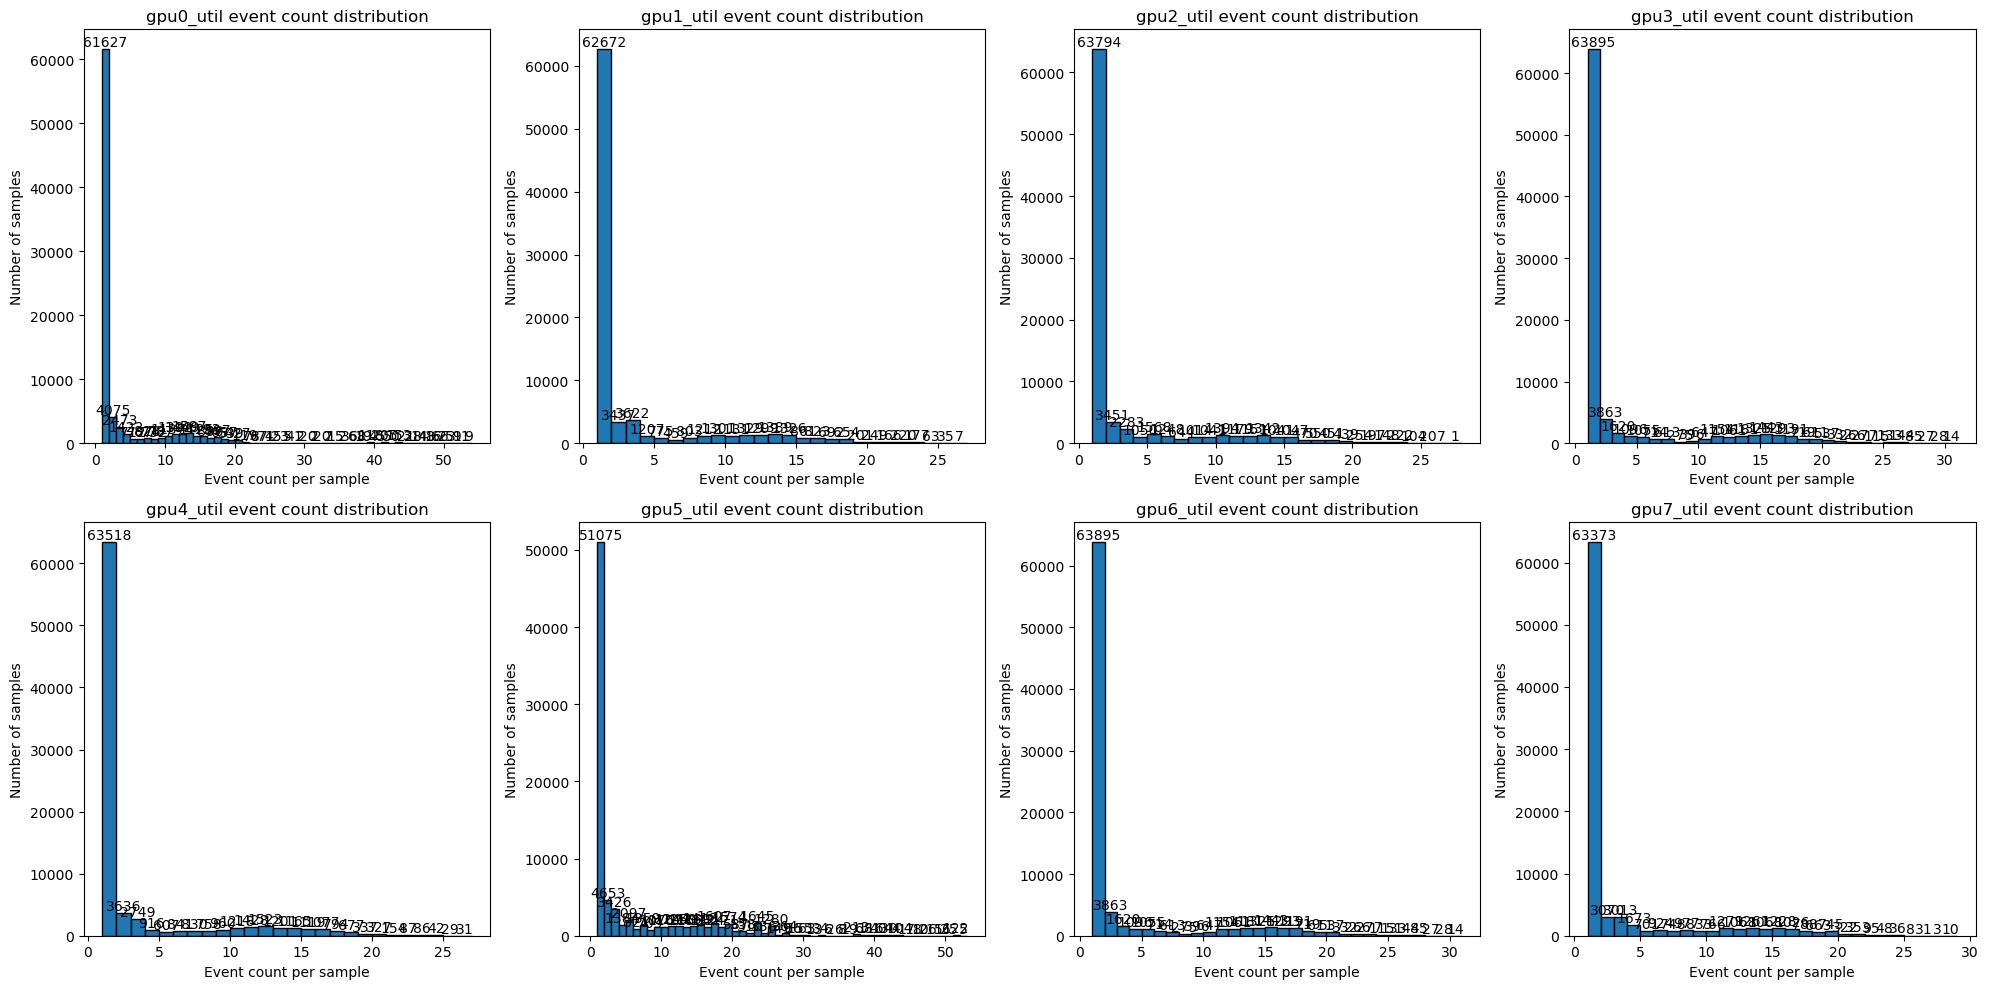

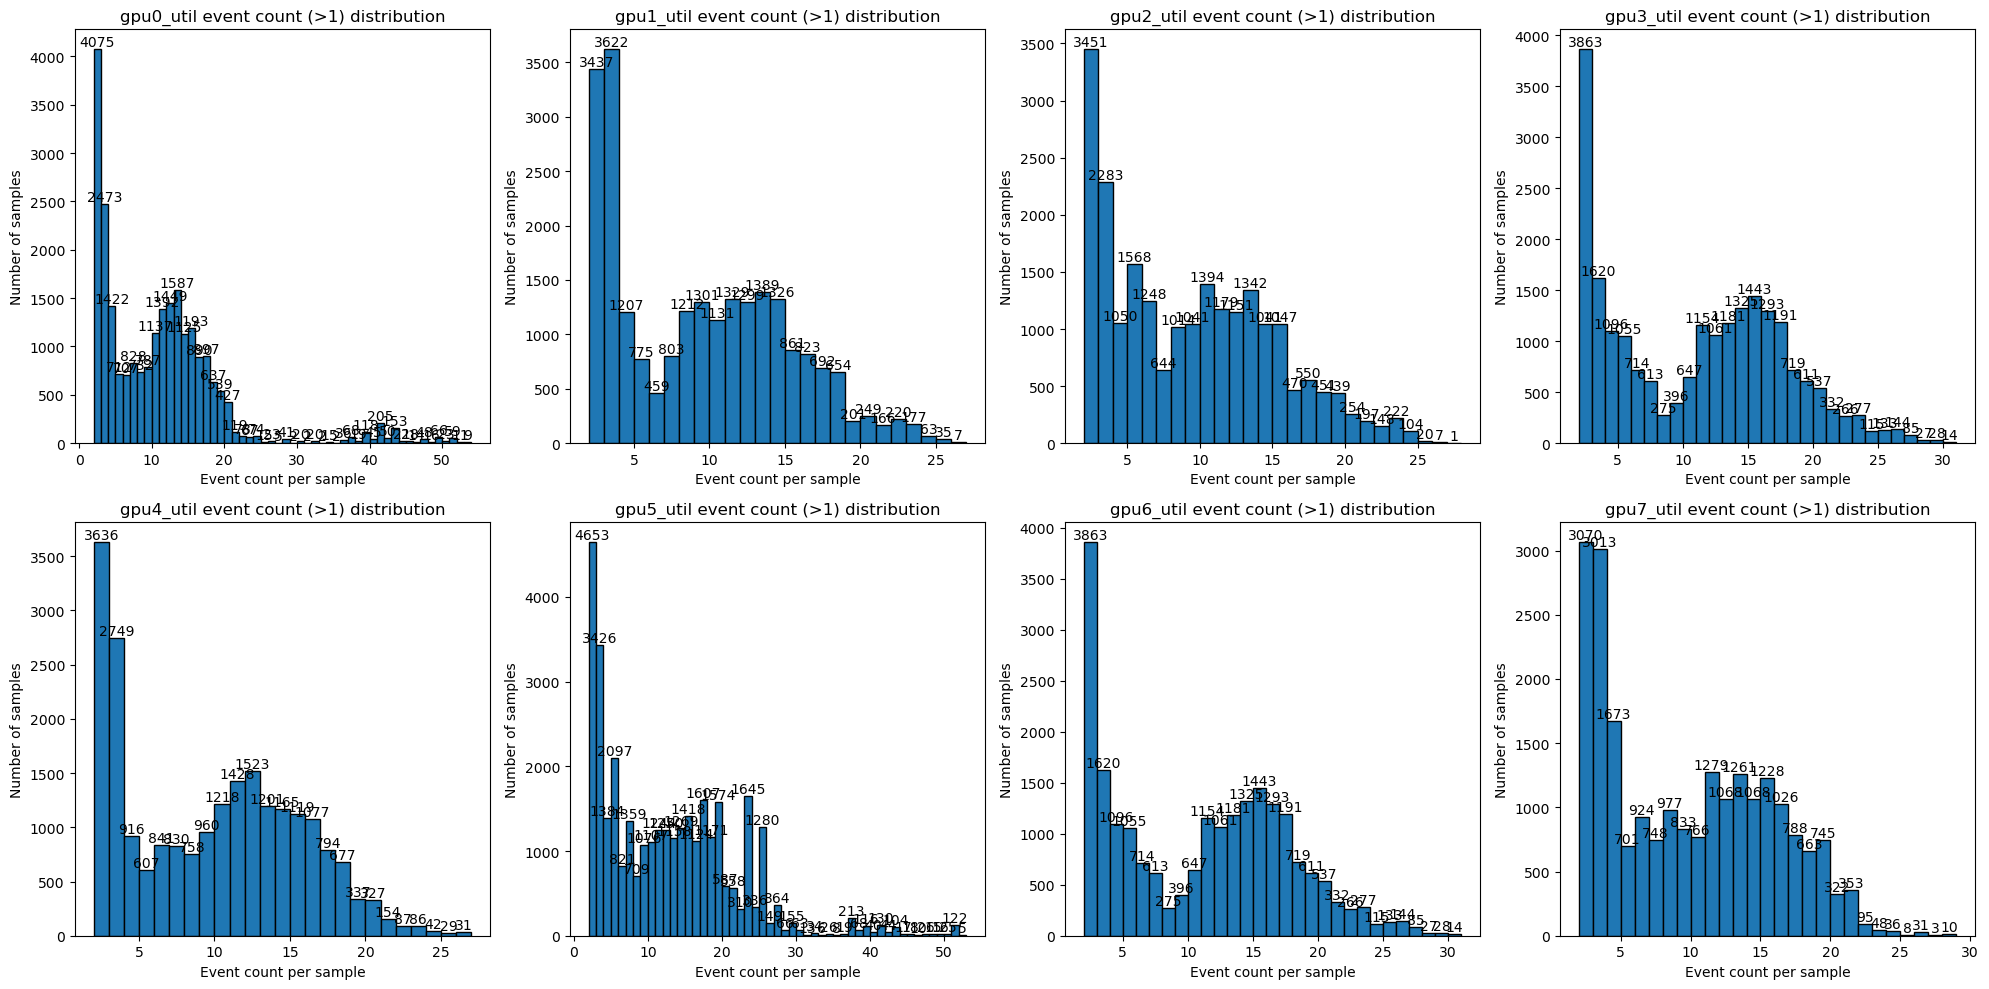

In [10]:
import matplotlib.pyplot as plt

columns_list = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']

# 第一张图：包含所有事件数量的直方图
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, column in enumerate(columns_list):
    event_data = event_samples[column]
    # 统计每个样本中事件的数量
    event_counts = [len(sample) for sample in event_data]
    bins = range(min(event_counts), max(event_counts) + 2)
    n, bins_, patches = axes[idx].hist(event_counts, bins=bins, edgecolor='black')
    axes[idx].set_title(f"{column} event count distribution")
    axes[idx].set_xlabel("Event count per sample")
    axes[idx].set_ylabel("Number of samples")
    # 在每个柱子上标注数量
    for count, left, right in zip(n, bins[:-1], bins[1:]):
        if count > 0:
            axes[idx].text((left + right) / 2, count, str(int(count)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 第二张图：去掉事件数量为1的样本
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))
axes2 = axes2.flatten()

for idx, column in enumerate(columns_list):
    event_data = event_samples[column]
    # 统计每个样本中事件的数量，并去掉事件数量为1的样本
    event_counts = [len(sample) for sample in event_data if len(sample) > 1]
    if len(event_counts) == 0:
        # 如果全是1，跳过
        axes2[idx].set_visible(False)
        continue
    bins = range(min(event_counts), max(event_counts) + 2)
    n, bins_, patches = axes2[idx].hist(event_counts, bins=bins, edgecolor='black')
    axes2[idx].set_title(f"{column} event count (>1) distribution")
    axes2[idx].set_xlabel("Event count per sample")
    axes2[idx].set_ylabel("Number of samples")
    # 在每个柱子上标注数量
    for count, left, right in zip(n, bins[:-1], bins[1:]):
        if count > 0:
            axes2[idx].text((left + right) / 2, count, str(int(count)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 固定历史事件数量

In [15]:
import pandas as pd

columns_list = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']

# 初始化突变点时间列全0
file_path = '../data/processed_data/1_datacenter.csv'
data = pd.read_csv(file_path)
data['timestamp'] = data['timestamp'].astype(str)
for col in columns_list:
    changetype_col = f"{col}_changetype"
    data[changetype_col] = 0

# 利用突变点数据填充对应时间的改变点类型， 1代表上升突变点，-1代表下降突变点
data = data.set_index('timestamp')
file_path = '../data/processed_data/change_points_dict.pkl'
all_change_points_data = pd.read_pickle(file_path)
for column in columns_list:
    changetype_col = f"{column}_changetype"
    change_points_data = all_change_points_data[column]
    change_points_data['timestamp'] = change_points_data['timestamp'].astype(str)
    for idx, row in change_points_data.iterrows():
        ts = row['timestamp']
        change_type = row['change_type']
        if ts in data.index:
            data.at[ts, changetype_col] = change_type

def timeseries_to_event_samples_by_count(
    data, 
    columns_list=['gpu0_util'], 
    k_history=3, 
    k_future=1
):
    """
    将时间序列数据转换为事件序列样本，固定历史事件数量为k_history，未来事件数量为k_future。
    返回一个字典，key为column名，value为该column的样本list。
    每个样本为事件list，每个事件为dict:
    {
        'idx_event': int,  # 该样本的第几个事件（从1开始）
        'type_event': int, # changetype, 1或-1
        'time_since_start': float, # 距离数据最开始index的秒数
        'time_since_last_event': float # 距离上一个事件的秒数
    }
    """
    # 确保索引为datetime
    if not pd.api.types.is_datetime64_any_dtype(data.index):
        data = data.copy()
        data.index = pd.to_datetime(data.index)

    min_time = data.index.min()
    max_time = data.index.max()

    samples_dict = {col: [] for col in columns_list}

    for column in columns_list:
        changetype_col = f"{column}_changetype"
        # 获取所有突变点事件（时间戳和类型）
        events = []
        for ts in data.index[data[changetype_col] != 0]:
            events.append((ts, int(data.at[ts, changetype_col])))
        # 按时间排序
        events = sorted(events, key=lambda x: x[0])
        n_events = len(events)
        # 滑动窗口采样
        for i in range(k_history, n_events - k_future + 1):
            # 历史k_history个事件
            history_events = events[i - k_history:i]
            # 未来k_future个事件
            future_events = events[i:i + k_future]
            all_events = history_events + future_events
            # 构造事件list
            event_list = []
            last_time = None
            for idx_e, (ts, type_event) in enumerate(all_events):
                time_since_start = (ts - min_time).total_seconds()
                if last_time is None:
                    time_since_last_event = 0.0
                else:
                    time_since_last_event = (ts - last_time).total_seconds()
                event_list.append({
                    'idx_event': idx_e + 1,
                    'type_event': 0 if type_event == -1 else type_event,
                    'time_since_start': time_since_start,
                    'time_since_last_event': time_since_last_event
                })
                last_time = ts
            samples_dict[column].append(event_list)
    return samples_dict
k_history=5
k_future=1
# 按固定历史事件数量和未来事件数量采样事件样本，返回字典
event_samples = timeseries_to_event_samples_by_count(
    data, 
    columns_list=['gpu0_util', 'gpu1_util','gpu2_util','gpu3_util','gpu4_util','gpu5_util','gpu6_util','gpu7_util'], 
    k_history=k_history,   # 历史事件数量
    k_future=k_future     # 未来事件数量
)
import pickle
with open(f'../data/processed_data/event_samples_past{k_history}_future{k_future}.pkl', 'wb') as f:
    pickle.dump(event_samples, f)
# print(data[[f"{col}_changetype" for col in columns_list]].head(20))

In [16]:
columns_list = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']
for column in columns_list:
    print(column,'样本数量:',len(event_samples[column]))
    print(event_samples[column][1][-1]['time_since_start'])
    print(event_samples[column][1][0]['time_since_start'])
    print(column,'样本时间跨度:',event_samples[column][1][-1]['time_since_start']-event_samples[column][1][0]['time_since_start'])

gpu0_util 样本数量: 979
167100.0
142800.0
gpu0_util 样本时间跨度: 24300.0
gpu1_util 样本数量: 765
167070.0
106200.0
gpu1_util 样本时间跨度: 60870.0
gpu2_util 样本数量: 729
167040.0
106200.0
gpu2_util 样本时间跨度: 60840.0
gpu3_util 样本数量: 877
160740.0
106170.0
gpu3_util 样本时间跨度: 54570.0
gpu4_util 样本数量: 771
167070.0
106200.0
gpu4_util 样本时间跨度: 60870.0
gpu5_util 样本数量: 1643
160770.0
106200.0
gpu5_util 样本时间跨度: 54570.0
gpu6_util 样本数量: 877
160740.0
106170.0
gpu6_util 样本时间跨度: 54570.0
gpu7_util 样本数量: 782
167100.0
142830.0
gpu7_util 样本时间跨度: 24270.0


In [ ]:
# 上一个框里面发现有些列突变点位置重合的，刚好检验一下
data.index=pd.to_datetime(data.index)
time_start=data.index.min()
print(time_start+pd.Timedelta(seconds=106200.0))
print(time_start+pd.Timedelta(seconds=143010.0))
print(data[['gpu1_util','gpu1_util_changetype','gpu2_util','gpu2_util_changetype','gpu3_util','gpu3_util_changetype']].loc['2025-07-30 15:11:00':'2025-07-30 15:13:30'])
print(data[['gpu1_util','gpu1_util_changetype','gpu2_util','gpu2_util_changetype','gpu3_util','gpu3_util_changetype']].loc['2025-07-31 01:24:30':'2025-07-31 01:26:30'])

2025-07-30 15:12:00
2025-07-31 01:25:30
                     gpu1_util  gpu1_util_changetype  gpu2_util  \
timestamp                                                         
2025-07-30 15:11:00        1.0                     0       1.00   
2025-07-30 15:11:30        1.0                     0       0.98   
2025-07-30 15:12:00        0.0                    -1       0.00   
2025-07-30 15:12:30        0.0                     0       0.00   
2025-07-30 15:13:00        0.0                     0       0.00   
2025-07-30 15:13:30        0.0                     0       0.00   

                     gpu2_util_changetype  gpu3_util  gpu3_util_changetype  
timestamp                                                                   
2025-07-30 15:11:00                     0       1.00                     0  
2025-07-30 15:11:30                     0       0.12                    -1  
2025-07-30 15:12:00                    -1       0.00                     0  
2025-07-30 15:12:30                   

### 可视化

/tmp/ipykernel_1852705/1760437869.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(loc='upper right', fontsize=10)


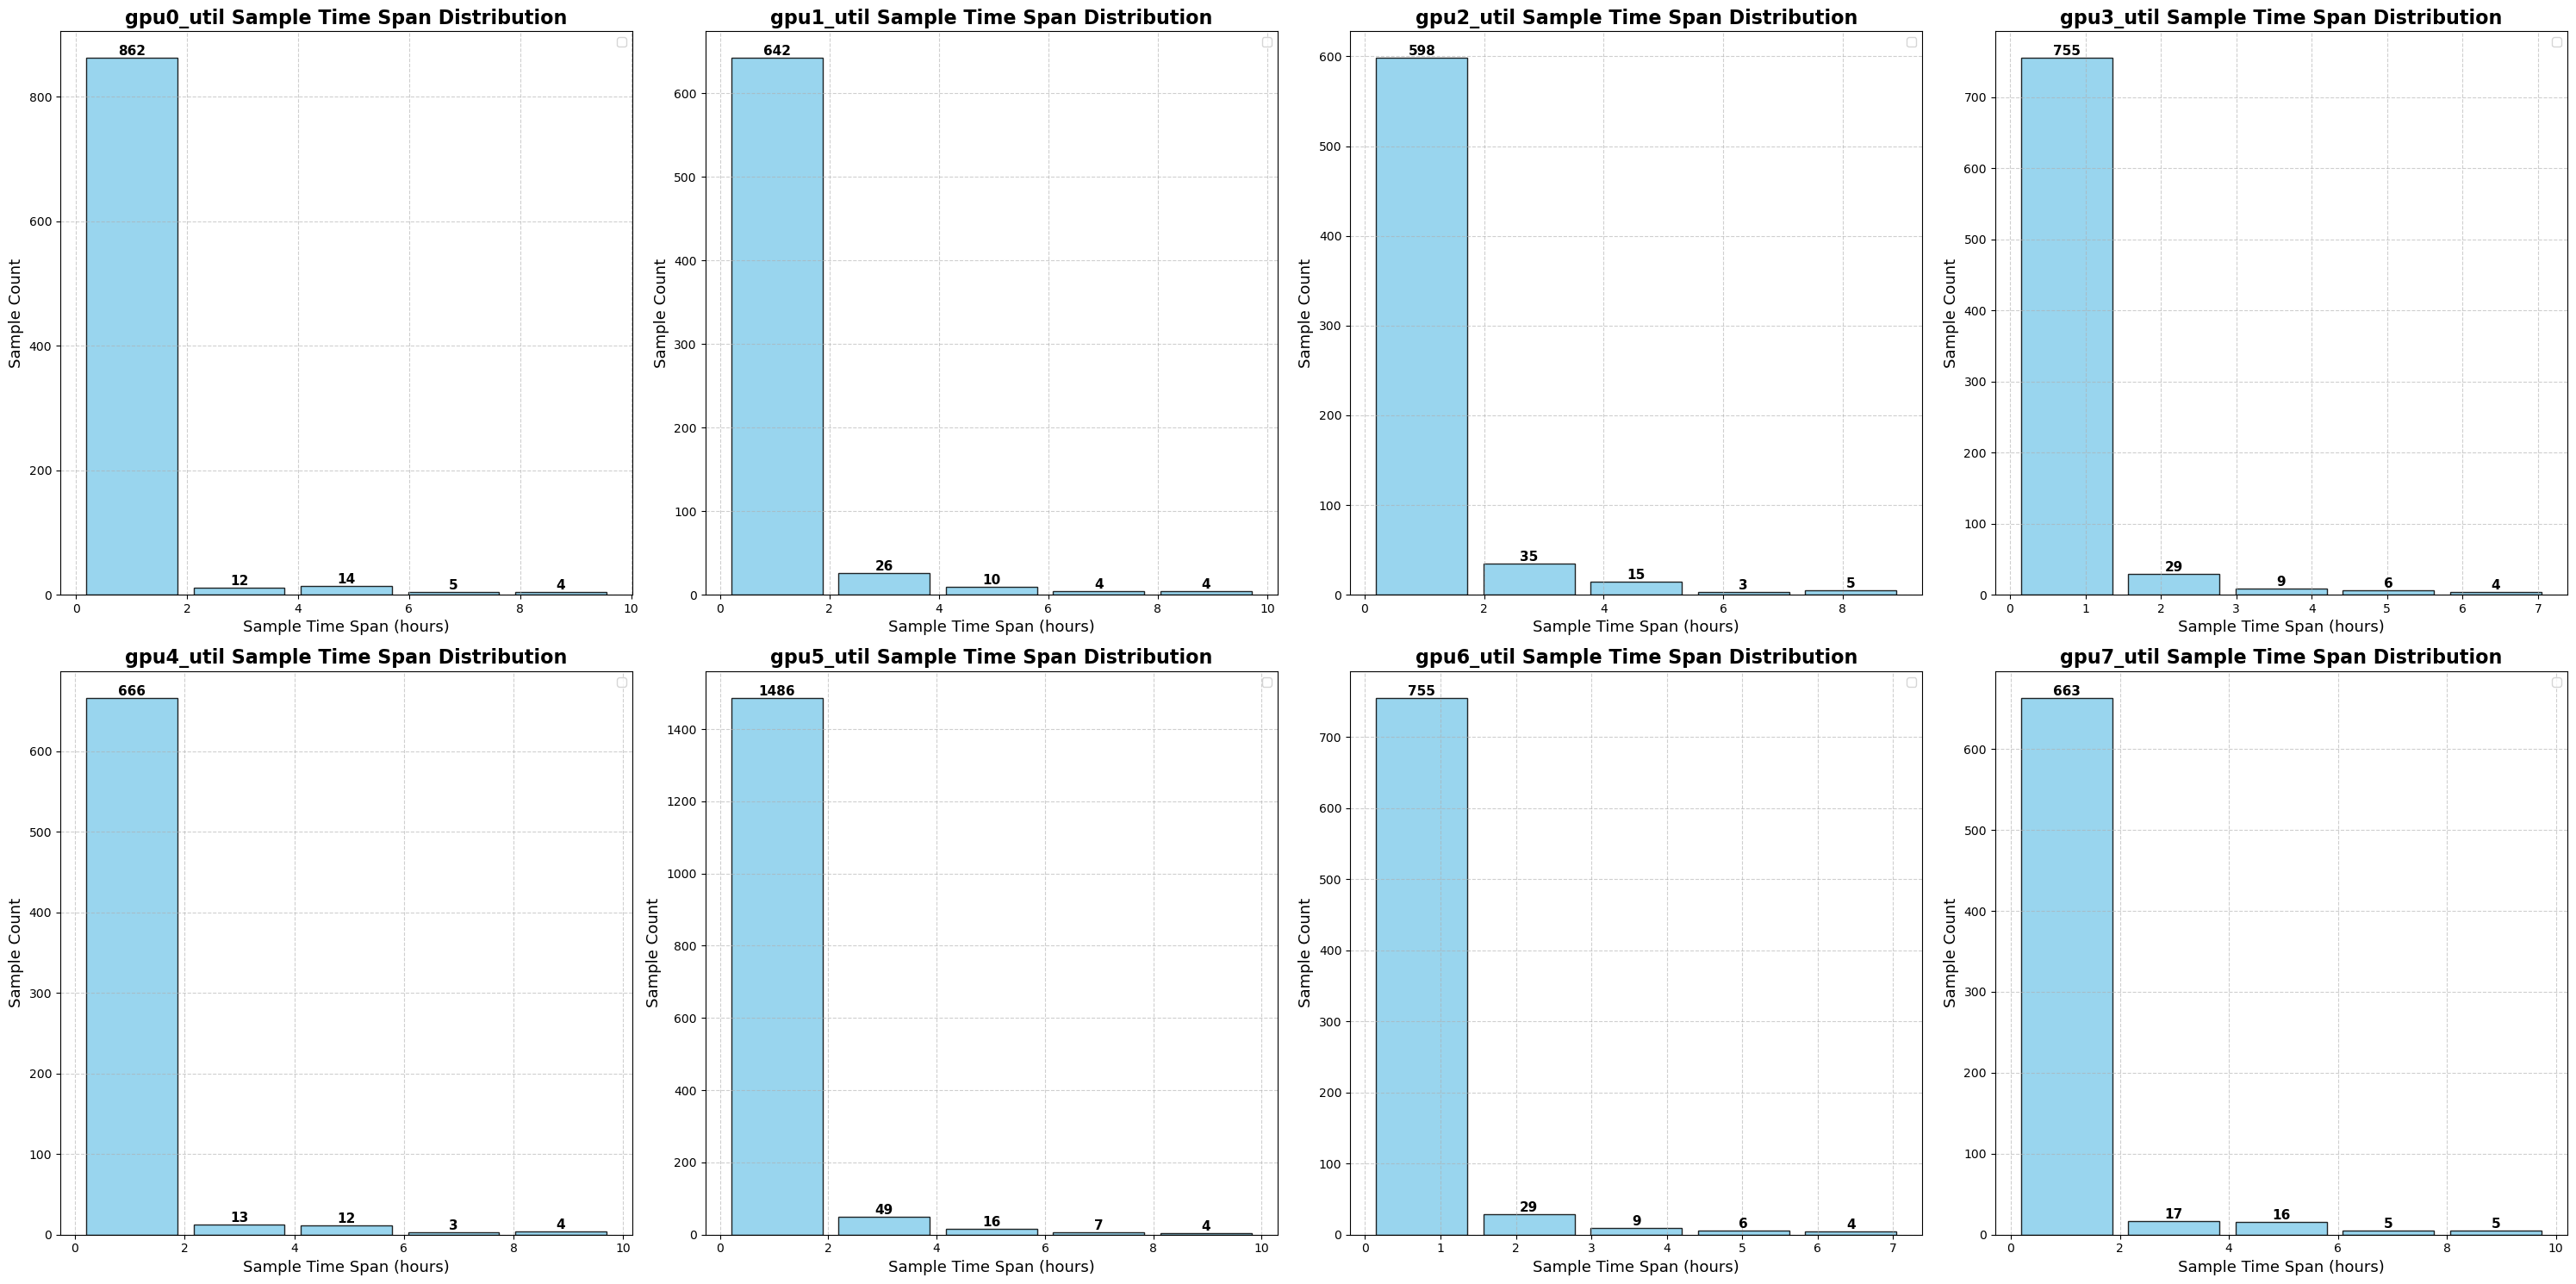

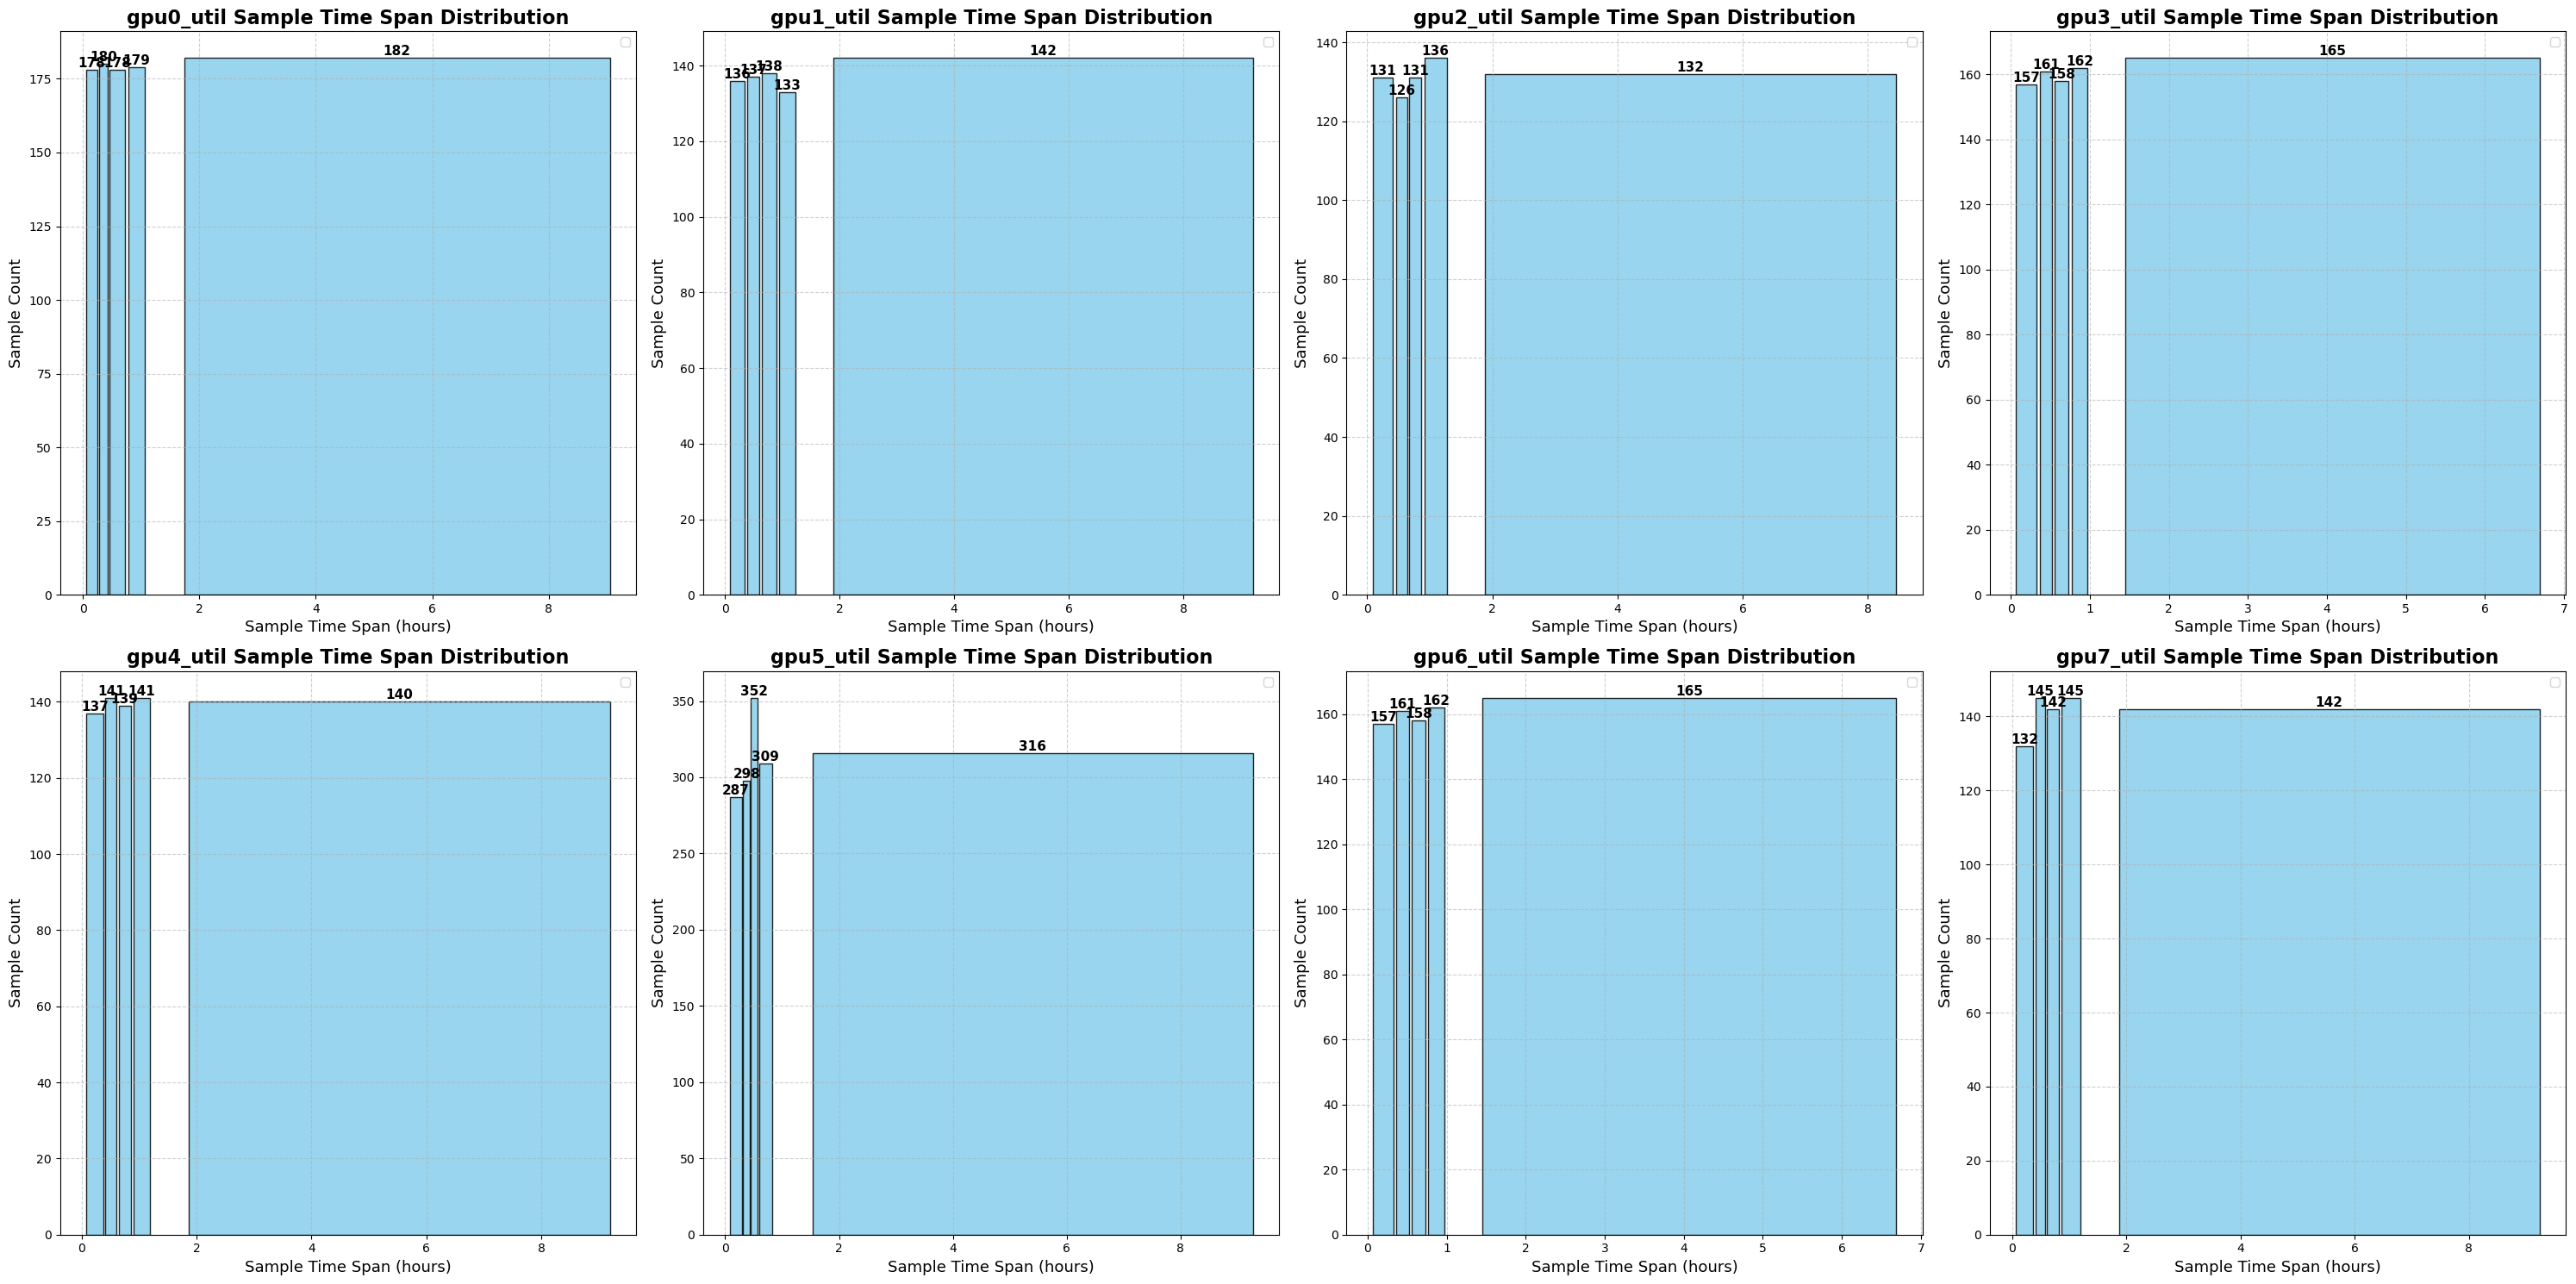

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_time_span_hist(event_samples, columns_list, bin_mode='time', n_bins=5, time_max_limit=1000):
    """
    绘制样本时间跨度分布直方图（横坐标以小时为单位）

    参数:
        event_samples: dict，每个key为列名，value为事件样本列表
        columns_list: list，待绘制的列名
        bin_mode: str，'time'表示均匀时间划分，'count'表示均匀样本数量划分
        n_bins: int，分箱数量
        time_max_limit: float，最大允许的时间跨度（秒），超过该值的样本不绘制
    """
    fig, axes = plt.subplots(2, 4, figsize=(30, 15))
    axes = axes.flatten()

    for idx, column in enumerate(columns_list):
        # 计算每个样本的时间跨度（秒）
        time_spans = []
        for sample in event_samples[column]:
            if len(sample) >= 2:
                span = sample[-1]['time_since_start'] - sample[0]['time_since_start']
                time_spans.append(span)
        # 过滤超过最大时间跨度的样本
        time_spans = [span for span in time_spans if span <= time_max_limit]
        if len(time_spans) == 0:
            axes[idx].set_visible(False)
            continue
        # 转换为小时
        time_spans_hour = [span / 3600 for span in time_spans]
        min_span_hour = min(time_spans_hour)
        max_span_hour = max(time_spans_hour)
        # 选择分箱方式
        if bin_mode == 'time':
            # 均匀时间划分（小时）
            bins = np.linspace(min_span_hour, max_span_hour, n_bins+1)
        elif bin_mode == 'count':
            # 均匀样本数量划分（小时）
            bins = np.percentile(time_spans_hour, np.linspace(0, 100, n_bins+1))
            bins = np.unique(bins)
            if len(bins) <= 1:
                bins = np.array([min_span_hour, max_span_hour])
        else:
            raise ValueError("bin_mode 只能为 'time' 或 'count'")
        n, bins_out, patches = axes[idx].hist(
            time_spans_hour, 
            bins=bins, 
            color='skyblue', 
            edgecolor='black',
            alpha=0.85,
            rwidth=0.85
        )
        # 标记最小和最大时间跨度
        # axes[idx].axvline(min_span_hour, color='red', linestyle='--', linewidth=2, label=f"Min: {min_span_hour:.2f}h")
        # axes[idx].axvline(max_span_hour, color='green', linestyle='--', linewidth=2, label=f"Max: {max_span_hour:.2f}h")
        # axes[idx].text(min_span_hour, max(n)*1.02, f"min: {min_span_hour:.2f}h", color='red', ha='left', va='bottom', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
        # axes[idx].text(max_span_hour, max(n)*1.02, f"max: {max_span_hour:.2f}h", color='green', ha='right', va='bottom', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='green'))
        # 在每个柱子上方标注数量
        for i in range(len(bins)-1):
            start = bins[i]
            end = bins[i+1]
            
            # axes[idx].text((start+end)/2, -max(n)*0.05, f"{int(start)}-{int(end)}h", color='blue', ha='center', va='top', fontsize=10, fontweight='bold')
            if i < len(n) and n[i] > 0:
                axes[idx].text((start+end)/2, n[i], f"{int(n[i])}", ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
        #
        axes[idx].set_title(f"{column} Sample Time Span Distribution", fontsize=16, fontweight='bold')
        axes[idx].set_xlabel("Sample Time Span (hours)", fontsize=13)
        axes[idx].set_ylabel("Sample Count", fontsize=13)
        axes[idx].grid(True, linestyle='--', alpha=0.6)
        axes[idx].legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

columns_list = ['gpu0_util', 'gpu1_util', 'gpu2_util', 'gpu3_util', 'gpu4_util', 'gpu5_util', 'gpu6_util', 'gpu7_util']

# 选择分箱方式：'time'为均匀时间划分，'count'为均匀样本数量划分
plot_time_span_hist(event_samples, columns_list, bin_mode='time', n_bins=5, time_max_limit=36000)
plot_time_span_hist(event_samples, columns_list, bin_mode='count', n_bins=5, time_max_limit=36000)